In [ ]:
import pandas as pd

In [7]:
from transformers import pipeline
from tqdm import tqdm

In [8]:
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment'
)

# Function to extract sentiment
def get_sentiment(text, max_len=512):
    text = text[:max_len]  # Truncate if too long
    result = sentiment_pipeline(text)[0]
    label = result['label']        # e.g., '2 stars'
    score = result['score']        # confidence
    stars = int(label[0])
    
    if stars <= 2: sentiment = 'Negative'
    elif stars == 3: sentiment = 'Neutral'
    else: sentiment = 'Positive'
    
    return sentiment, stars, score


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [18]:
df = pd.read_csv("../data/processed/preprocessed_reviews.csv")

tqdm.pandas()
df[['sentiment', 'predicted_stars', 'confidence']] = df['text_for_sentiment'].progress_apply(
    lambda x: pd.Series(get_sentiment(x))
)

df.to_csv("../data/processed/reviews_with_summaries.csv", index=False)

100%|██████████| 5000/5000 [04:49<00:00, 17.25it/s]


In [19]:
from sklearn.metrics import classification_report

# Mmapping actual star ratings to sentiment
def rating_to_sentiment(r):
    if r <= 2: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

df['actual_sentiment'] = df['star_rating'].apply(rating_to_sentiment)
df.to_csv("../data/processed/reviews_with_summaries.csv", index=False)

# Classification metrics
print(classification_report(df['actual_sentiment'], df['sentiment']))

              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89       864
     Neutral       0.86      0.60      0.71       615
    Positive       0.98      0.98      0.98      3521

    accuracy                           0.93      5000
   macro avg       0.88      0.86      0.86      5000
weighted avg       0.94      0.93      0.93      5000



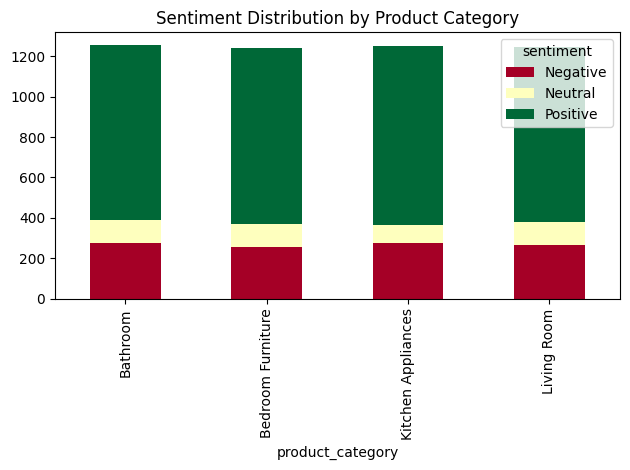

In [20]:
import matplotlib.pyplot as plt

sentiment_by_cat = df.groupby(['product_category', 'sentiment']).size().unstack(fill_value=0)

sentiment_by_cat.plot(kind='bar', stacked=True, colormap='RdYlGn')
plt.title('Sentiment Distribution by Product Category')
plt.tight_layout()
plt.savefig('sentiment_by_category.png')